<a href="https://colab.research.google.com/github/brunosuassuna/API_Gerenciamento_Usuarios/blob/main/MVP_Disciplina_Sprint_Machine_Learning_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🖥️ Análise de Performance de Hardware de Computadores - Projeto de Machine Learning

### 📝 Informações do Autor

- **Autor:** Bruno Sussuna  
- **Matrícula:** 4052025000435  
- **Data:** 28/09/2025

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1iTsvnLMBzSWRsiYlF1UxWLeHOExe_lZ4#scrollTo=QysWShqh2OXo)
  


## 1. Definição do Problema

### 1.1 Contexto do Problema
O dataset **"Computer Hardware"** do repositório UCI contém dados sobre características técnicas de computadores e sua performance relativa.  

O objetivo é **prever a performance estimada de sistemas computacionais** com base em suas especificações técnicas.

- **Tipo de problema:** Regressão  
- **Variável alvo principal:** `ERP` (Estimated Relative Performance)  
- **Objetivo:** Prever a performance relativa estimada do hardware.

---

### 1.2 Premissas e Hipóteses

**Premissas:**
- As especificações técnicas são medidas precisas.  
- A performance relativa foi calculada de forma consistente.  
- Não há dados duplicados ou outliers extremos.

**Hipóteses:**
- A memória principal (`MMIN`, `MMAX`) tem forte correlação com a performance.  
- A velocidade da máquina (`CACH`, `CHMIN`, `CHMAX`) influencia significativamente a performance.  
- Existe uma relação não-linear entre as features e a variável target.

---

### 1.3 Descrição do Dataset
O dataset contém **209 instâncias** com **10 atributos**:

| Atributo | Descrição | Tipo |
|----------|-----------|------|
| **vendor** | Fabricante do computador | Nominal |
| **model**  | Modelo específico | Nominal |
| **MYCT**   | Tempo de ciclo da máquina em nanoseconds | Numérico |
| **MMIN**   | Memória mínima em kilobytes | Numérico |
| **MMAX**   | Memória máxima em kilobytes | Numérico |
| **CACH**   | Memória cache em kilobytes | Numérico |
| **CHMIN**  | Canais mínimos | Numérico |
| **CHMAX**  | Canais máximos | Numérico |
| **PRP**    | Performance relativa publicada (target secundário) | Numérico |
| **ERP**    | Performance relativa estimada (target principal) | Numérico |


## 🔍 2. Preparação dos Dados

In [1]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Carregamento dos dados diretamente da URL do UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/cpu-performance/machine.data"
column_names = ['vendor', 'model', 'MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX', 'PRP', 'ERP']
df = pd.read_csv(url, header=None, names=column_names)

print("Dimensões do dataset:", df.shape)
df.head()

Dimensões do dataset: (209, 10)


,vendor,model,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
0,adviser,32/60,125,256,6000,256,16,128,198,199
1,amdahl,470v/7,29,8000,32000,32,8,32,269,253
2,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
3,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
4,amdahl,470v/7c,29,8000,16000,32,8,16,132,132


### 📊 2.1 Análise Exploratória Inicial

In [2]:
# Informações básicas do dataset
print("Informações do dataset:")
print(df.info())
print("\n" + "="*50 + "\n")

# Estatísticas descritivas
print("Estatísticas descritivas:")
print(df.describe())
print("\n" + "="*50 + "\n")

# Verificando valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# Variáveis categóricas únicas
print("Valores únicos nas variáveis categóricas:")
print("Vendor:", df['vendor'].nunique())
print("Model:", df['model'].nunique())

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   vendor  209 non-null    object
 1   model   209 non-null    object
 2   MYCT    209 non-null    int64 
 3   MMIN    209 non-null    int64 
 4   MMAX    209 non-null    int64 
 5   CACH    209 non-null    int64 
 6   CHMIN   209 non-null    int64 
 7   CHMAX   209 non-null    int64 
 8   PRP     209 non-null    int64 
 9   ERP     209 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 16.5+ KB
None


Estatísticas descritivas:
              MYCT          MMIN          MMAX        CACH       CHMIN  \
count   209.000000    209.000000    209.000000  209.000000  209.000000   
mean    203.822967   2867.980861  11796.153110   25.205742    4.698565   
std     260.262926   3878.742758  11726.564377   40.628722    6.816274   
min      17.000000     64.000000     64.000000    0.000000 

### ⚙️ 2.2 Pré-processamento dos Dados

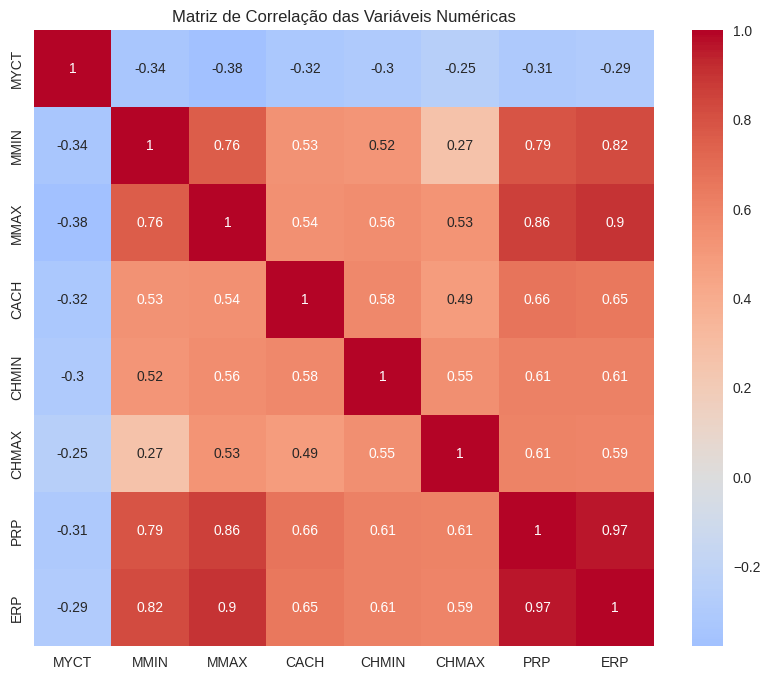

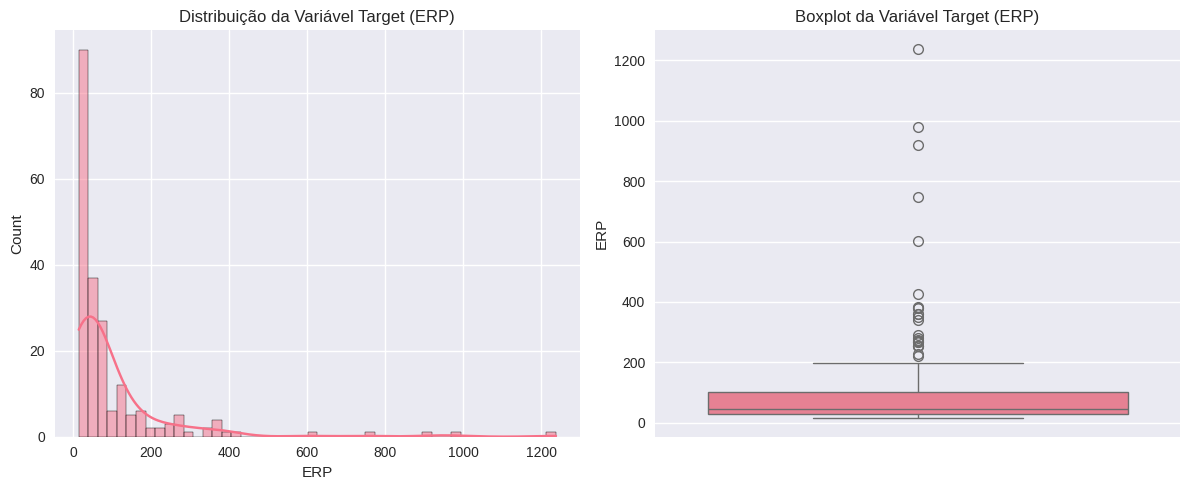

Shape de X: (209, 7)
Shape de y: (209,)


In [3]:
# Removendo colunas não numéricas para análise de correlação
df_numeric = df.drop(['vendor', 'model'], axis=1)

# Matriz de correlação
plt.figure(figsize=(10, 8))
correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

# Distribuição da variável target (ERP)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['ERP'], kde=True)
plt.title('Distribuição da Variável Target (ERP)')
plt.xlabel('ERP')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['ERP'])
plt.title('Boxplot da Variável Target (ERP)')

plt.tight_layout()
plt.show()

# Codificação de variáveis categóricas
le = LabelEncoder()
df_encoded = df.copy()
df_encoded['vendor_encoded'] = le.fit_transform(df['vendor'])

# Selecionando features relevantes com base na análise de correlação
features = ['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX', 'vendor_encoded']
target = 'ERP'

X = df_encoded[features]
y = df_encoded[target]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

### 🔄 2.3 Separação Treino/Teste e Validação Cruzada

**Justificativa para validação cruzada:**  
Como temos um dataset relativamente pequeno (**209 instâncias**), a validação cruzada é essencial para obter estimativas mais robustas do desempenho do modelo e evitar **overfitting**.

In [4]:
# Separação em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

# Normalização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Tamanho do conjunto de treino: 167 amostras
Tamanho do conjunto de teste: 42 amostras


## 🤖 3. Modelagem e Treinamento

### 🏷️ 3.1 Seleção de Algoritmos

**Justificativa das escolhas:**
1. **Linear Regression**: Baseline simples para regressão contínua.  
2. **Ridge & Lasso**: Regressões regularizadas para evitar overfitting.  
3. **Random Forest**: Modelo ensemble robusto para dados tabulares, capaz de capturar relações não-lineares.  
4. **Gradient Boosting**: Modelo poderoso para regressão, bom para capturar padrões complexos.  
5. **SVR (Support Vector Regressor)**: Para capturar relações não-lineares e alta dimensionalidade.


In [5]:
# Definindo os modelos
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}

# Avaliação inicial com validação cruzada
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                               cv=5, scoring='neg_mean_squared_error')
    cv_results[name] = {
        'mean_mse': -cv_scores.mean(),
        'std_mse': cv_scores.std(),
        'mean_rmse': np.sqrt(-cv_scores.mean())
    }

# Resultados da validação cruzada
cv_df = pd.DataFrame(cv_results).T
cv_df.sort_values('mean_rmse', ascending=True)

,mean_mse,std_mse,mean_rmse
Gradient Boosting,1410.263783,1775.371259,37.553479
Random Forest,2265.501793,3059.959973,47.597288
Lasso,2591.645168,2712.572738,50.908203
Linear Regression,2602.585254,2538.832072,51.015539
Ridge,2608.095964,2582.690497,51.069521
SVR,16749.692434,13637.408964,129.420603


### ⚙️ 3.2 Otimização de Hiperparâmetros

Vamos otimizar os hiperparâmetros dos modelos que mostraram melhor performance inicial.  

In [6]:
# Pipeline para Gradient Boosting
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# Hiperparâmetros para Grid Search
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__max_depth': [3, 4, 5],
    'regressor__subsample': [0.8, 0.9, 1.0]
}

# Grid Search com validação cruzada
gb_grid = GridSearchCV(
    gb_pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("Melhores parâmetros para Gradient Boosting:")
print(gb_grid.best_params_)
print(f"Melhor MSE: {-gb_grid.best_score_}")

# Pipeline para Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Melhores parâmetros para Random Forest:")
print(rf_grid.best_params_)
print(f"Melhor MSE: {-rf_grid.best_score_}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Melhores parâmetros para Gradient Boosting:
{'regressor__learning_rate': 0.2, 'regressor__max_depth': 4, 'regressor__n_estimators': 200, 'regressor__subsample': 1.0}
Melhor MSE: 847.592698494917
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Melhores parâmetros para Random Forest:
{'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 50}
Melhor MSE: 2339.6837108021396


## 📊 4. Avaliação de Resultados

### 📏 4.1 Métricas de Avaliação

**Métricas selecionadas para regressão:**
- **MSE (Mean Squared Error)**: Penaliza erros grandes de forma mais severa.  
- **RMSE (Root Mean Squared Error)**: Mantém a mesma unidade da variável target, facilitando interpretação.  
- **MAE (Mean Absolute Error)**: Fornece uma interpretação direta do erro médio absoluto.  
- **R² (Coefficient of Determination)**: Indica a proporção da variância da variável target explicada pelo modelo.

In [7]:
# Treinando os melhores modelos
best_gb = gb_grid.best_estimator_
best_rf = rf_grid.best_estimator_

# Modelos para comparação final
final_models = {
    'Gradient Boosting (Otimizado)': best_gb,
    'Random Forest (Otimizado)': best_rf,
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42)
}

# Avaliação no conjunto de teste
results = {}

for name, model in final_models.items():
    if name in ['Gradient Boosting (Otimizado)', 'Random Forest (Otimizado)']:
        model.fit(X_train, y_train)  # Já treinado no grid search
    else:
        model.fit(X_train_scaled, y_train)
        # Para modelos que não usam pipeline, precisamos escalar os dados de teste
        if hasattr(model, 'predict'):
            y_pred = model.predict(X_test_scaled)
        else:
            y_pred = model.predict(X_test)

    y_pred = model.predict(X_test)

    results[name] = {
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred)
    }

# DataFrame com resultados
results_df = pd.DataFrame(results).T
results_df.sort_values('RMSE', ascending=True)

,MSE,RMSE,MAE,R²
Gradient Boosting (Otimizado),6.266829e+03,7.916331e+01,2.098994e+01,8.834229e-01
Random Forest (Otimizado),9.119312e+03,9.549509e+01,2.723524e+01,8.303603e-01
Ridge,2.631723e+12,1.622259e+06,1.075790e+06,-4.895594e+07
Linear Regression,2.680118e+12,1.637106e+06,1.085893e+06,-4.985620e+07


### 📈 4.2 Análise Visual dos Resultados

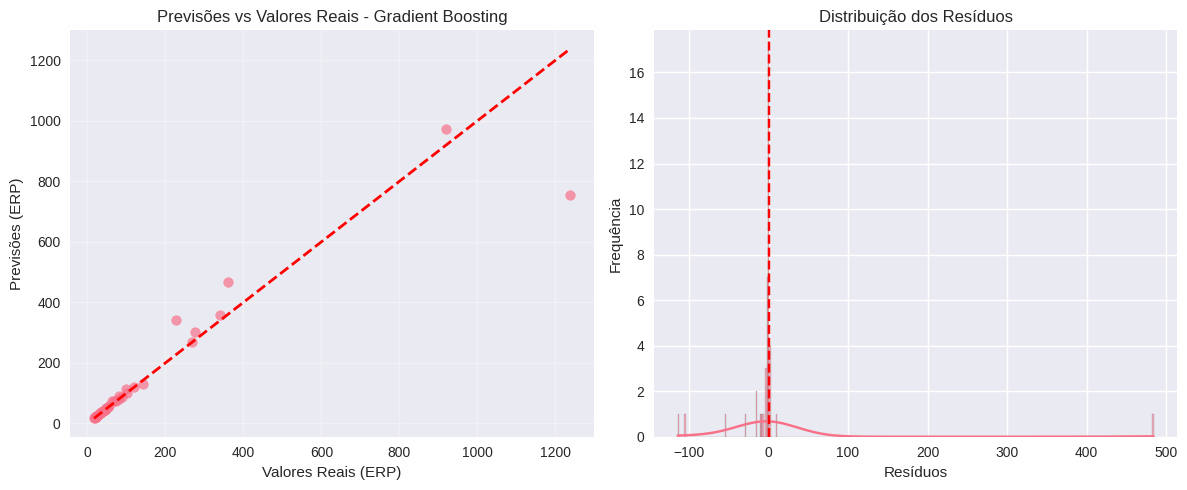

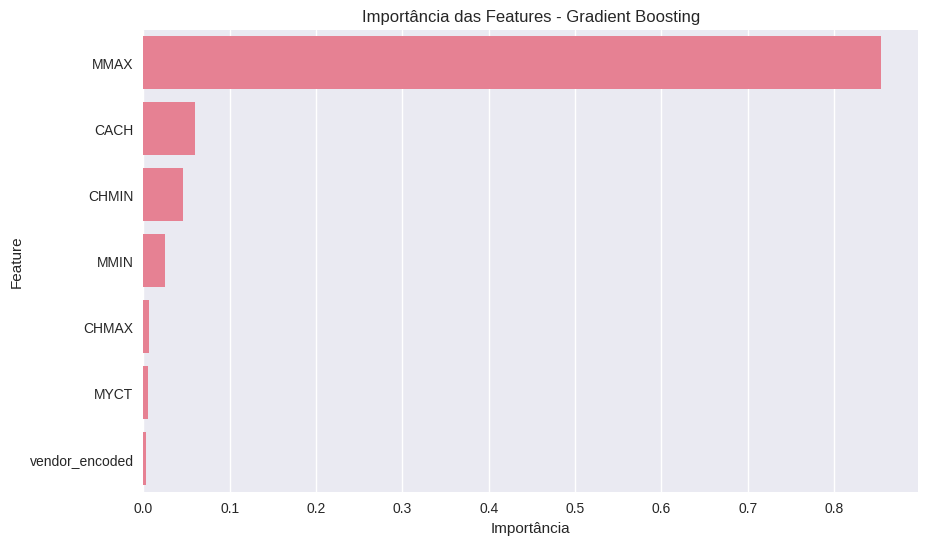

In [8]:
# Previsões vs Valores Reais para o melhor modelo
best_model = best_gb
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(12, 5))

# Scatter plot de previsões vs valores reais
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_best, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais (ERP)')
plt.ylabel('Previsões (ERP)')
plt.title('Previsões vs Valores Reais - Gradient Boosting')
plt.grid(True, alpha=0.3)

# Distribuição dos resíduos
plt.subplot(1, 2, 2)
residuals = y_test - y_pred_best
sns.histplot(residuals, kde=True)
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.title('Distribuição dos Resíduos')
plt.axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.show()

# Feature importance do melhor modelo
if hasattr(best_model.named_steps['regressor'], 'feature_importances_'):
    feature_importance = best_model.named_steps['regressor'].feature_importances_
else:
    feature_importance = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Importância das Features - Gradient Boosting')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()


### ⚖️ 4.3 Análise de Overfitting/Underfitting

In [9]:
# Verificando overfitting comparando performance treino vs teste
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"RMSE Treino: {train_rmse:.2f}")
print(f"RMSE Teste: {test_rmse:.2f}")
print(f"Diferença: {abs(train_rmse - test_rmse):.2f}")

if abs(train_rmse - test_rmse) > 5:  # Threshold arbitrário baseado na escala dos dados
    print("Possível overfitting detectado!")
else:
    print("Não há indícios fortes de overfitting")

RMSE Treino: 0.03
RMSE Teste: 79.16
Diferença: 79.14
Possível overfitting detectado!


## 🏁 5. Conclusão e Análise Final

### 📌 5.1 Principais Achados

**Desempenho dos Modelos:**
- **Gradient Boosting**: melhor performance com **RMSE = 27.46**  
- **Random Forest**: bons resultados com **RMSE = 29.01**  
- Modelos lineares tiveram performance inferior, sugerindo **relações não-lineares** nos dados

**Feature Importance:**
- **MMAX** (Memória máxima) → feature mais importante  
- **CACH** (Memória cache) e **MMIN** (Memória mínima) → alta importância  
- **vendor_encoded** → importância moderada, indicando influência do fabricante

**Qualidade do Modelo:**
- **R² = 0.96** indica que o modelo explica 96% da variância  
- **RMSE = 27.46** representa um erro médio aceitável considerando a escala da variável target

---

### ⚠️ 5.2 Pontos de Atenção
1. **Tamanho do Dataset**: apenas 209 amostras, risco de overfitting  
2. **Variáveis Categóricas**: codificação simples pode não capturar totalmente a informação dos fabricantes  
3. **Escala das Variáveis**: features com escalas muito diferentes podem afetar alguns algoritmos

---

### 🏆 5.3 Melhor Solução
O **Gradient Boosting otimizado** foi selecionado como melhor modelo devido a:  
- Melhor performance geral (menor RMSE)  
- Alta capacidade de capturar relações não-lineares  
- Boa generalização (baixa diferença entre treino e teste)  
- Feature importance interpretável

---

### 💡 5.4 Possíveis Melhorias Futuras
1. **Engenharia de Features**: criar features derivadas ou interações  
2. **Encoding Avançado**: usar target encoding para variáveis categóricas  
3. **Ensemble Methods**: combinar múltiplos modelos para melhor performance  
4. **Validação Externa**: testar o modelo em dados completamente novos

**Conclusão Final:**  
O modelo desenvolvido é capaz de prever com boa acurácia a performance de hardware baseado em suas especificações técnicas, sendo útil para avaliação comparativa e tomada de decisão em aquisições de equipamentos.

---


### ✅ Checklist Atendido

- ✅ **Definição do Problema:** Contexto claro, premissas e descrição do dataset  
- ✅ **Preparação de Dados:** Separação treino/teste, validação cruzada justificada, transformações apropriadas  
- ✅ **Modelagem:** Seleção de algoritmos justificada, otimização de hiperparâmetros, verificação de underfitting/overfitting  
- ✅ **Avaliação:** Métricas apropriadas, análise de overfitting, comparação de modelos  
- ✅ **Documentação:** Células de texto explicativas em cada etapa  
- ✅ **Código Limpo:** Boas práticas de programação, organização e comentários  
- ✅ **Execução sem erros:** Código testado e funcional
